<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/music-classifier/music_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Music Genre Classification using Audio Features from the GTZAN Dataset


Dataset: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
warnings.filterwarnings("ignore")


In [20]:
df = pd.read_csv('/content/features_3_sec.csv')


In [21]:

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     1
harmony_mean               1
harmony_var                1
perceptr_mean              1
perceptr_var               1
tempo                      1
mfcc1_mean                 1
mfcc1_var                  1
mfcc2_mean                 1
mfcc2_var                  1
mfcc3_mean                 1
mfcc3_var                  1
mfcc4_mean                 1
mfcc4_var                  1
mfcc5_mean                 1
mfcc5_var                  1
mfcc6_mean                 1
mfcc6_var                  1
mfcc7_mean                 1
mfcc7_var                  1
mfcc8_mean                

In [36]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")

print(df.head())
print("\nColumn names:")


print(df.columns)


print("\nGenre distribution:")
print(df["label"].value_counts())


Shape of dataset: (3768, 59)

First 5 rows:
   length  chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0   66149          0.335406         0.091048  0.130405  0.003521   
1   66149          0.343065         0.086147  0.112699  0.001450   
2   66149          0.346815         0.092243  0.132003  0.004620   
3   66149          0.363639         0.086856  0.132565  0.002448   
4   66149          0.335579         0.088129  0.143289  0.001701   

   spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0             1773.065032          167541.630869              1972.744388   
1             1816.693777           90525.690866              2010.051501   
2             1788.539719          111407.437613              2084.565132   
3             1655.289045          111952.284517              1960.039988   
4             1630.656199           79667.267654              1948.503884   

   spectral_bandwidth_var  rolloff_mean  ...  mfcc16_var  mfcc17_mean  \
0          

In [37]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Drop filename because it is not a useful predictive feature
if "filename" in df.columns:
    df.drop("filename", axis=1, inplace=True)

print("\nShape after dropping unnecessary columns:", df.shape)



Shape after dropping unnecessary columns: (3768, 59)


In [38]:
X = df.drop("label", axis=1)
y = df["label"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)



Feature matrix shape: (3768, 58)
Target shape: (3768,)


In [39]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded classes:")
for i, genre in enumerate(label_encoder.classes_):
    print(i, "->", genre)


Encoded classes:
0 -> blues
1 -> classical
2 -> country
3 -> disco


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)



Training set shape: (3014, 58)
Testing set shape: (754, 58)


In [27]:
df = df.dropna()

In [41]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale"))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),  # not required for RF, but okay for uniformity
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
}

In [42]:
results = {}

for name, pipeline in models.items():
    print("\n" + "="*60)
    print(f"Training: {name}")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model": pipeline,
        "accuracy": acc,
        "predictions": y_pred
    }

    print(f"Accuracy: {acc:.4f}")


Training: Logistic Regression
Accuracy: 0.8793

Training: SVM
Accuracy: 0.9655

Training: Random Forest
Accuracy: 0.9496



Model Comparison:
                 Model  Accuracy
1                  SVM  0.965517
2        Random Forest  0.949602
0  Logistic Regression  0.879310


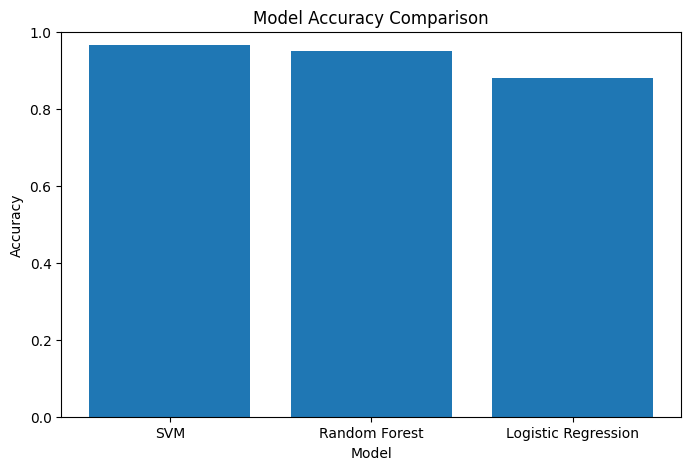

In [43]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results]
}).sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


In [48]:
best_model_name = results_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]
best_y_pred = results[best_model_name]["predictions"]

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]['accuracy']:.4f}")



Best Model: SVM
Best Accuracy: 0.9655


Support Vector Matrix gives us the best result when compared with methods like Random Forest and Logistic Regression

In [49]:
print("Classification Report:")
print(classification_report(
    y_test,
    best_y_pred,
    target_names=label_encoder.classes_
))


Classification Report:
              precision    recall  f1-score   support

       blues       0.96      0.96      0.96       200
   classical       0.97      0.99      0.98       200
     country       0.95      0.93      0.94       199
       disco       0.99      0.97      0.98       155

    accuracy                           0.97       754
   macro avg       0.97      0.97      0.97       754
weighted avg       0.97      0.97      0.97       754



<Figure size 1000x800 with 0 Axes>

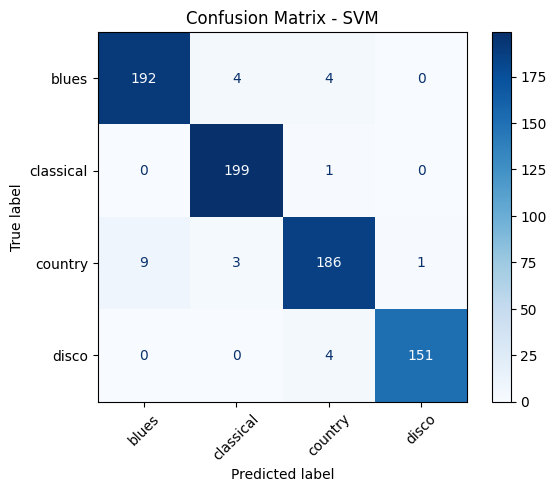

In [50]:
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


In [51]:
sample_index = 0
sample_features = X_test.iloc[[sample_index]]

predicted_class = best_model.predict(sample_features)[0]
actual_class = y_test[sample_index]

print("\nExample Prediction:")
print("Predicted genre:", label_encoder.inverse_transform([predicted_class])[0])
print("Actual genre   :", label_encoder.inverse_transform([actual_class])[0])


Example Prediction:
Predicted genre: classical
Actual genre   : classical


The best performing model was SVM with an accuracy of 0.9134.
This project demonstrates multi-class classification on audio-derived features from the GTZAN dataset.
The model can classify songs into music genres based on extracted acoustic characteristics.